In [11]:
from pyrocko import model

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize, LinearSegmentedColormap

from datetime import datetime

import yaml

# CLASS TO LOAD .YAML FILES AND READ PARAMENTER RESULTS
class IgnoreTagsLoader(yaml.SafeLoader):
    pass

def ignore_unknown(loader, tag_suffix, node):
    if isinstance(node, yaml.MappingNode):
        return loader.construct_mapping(node)
    elif isinstance(node, yaml.SequenceNode):
        return loader.construct_sequence(node)
    else:
        return loader.construct_scalar(node)

IgnoreTagsLoader.add_multi_constructor('!', ignore_unknown)

In [12]:
workdir='../'

plotdir=os.path.join(workdir,'PLOTS')
plotdir=os.path.join(plotdir,'VLP_VT_magnitude')
os.makedirs(plotdir, exist_ok=True)
plot_filename=os.path.join(plotdir,'vlp_vt_magnitude.pdf')

catdir=os.path.join(workdir,'CAT')
catname=os.path.join(catdir,'catalogue_flegrei_VLP.pf')                 # CHANGE
refevents=model.load_events(catname)
mttargets = [ev for ev in refevents]

badmtsols = ['']    # exclude some events
print(f'Catalogue: {catname}')
print('All events in catalogue:', len(mttargets))
goodmttargets = [ev for ev in mttargets if ev.name not in badmtsols]
print('Good events in catalogue:', len(goodmttargets))

# VLP magnitude -> y axis: composite inversion, source prefix 'vlp'
vlp_reportdir = '/Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report'
vlp_inversions = ['cmt_composite_LF_std_']                            # CHANGE
vlp_par = 'vlp.magnitude'

# VT magnitude -> x axis: deviatoric inversion, single source (no prefix)
vt_reportdir = '/Users/giaco/UNI/PhD_CODE/GIT/CAMPI_FLEGREI_moment_tensor/report'
vt_inversions = ['cmt_devi_XXL_final_', 'cmt_devi_XL_final_', 'cmt_devi_L_final_',
                 'cmt_devi_M_final_', 'cmt_devi_S_final_', 'cmt_devi_S_']   # CHANGE
vt_par = 'magnitude'

print(f'\nVLP inversions selected: {vlp_inversions}  -> parameter {vlp_par}')
print(f'VT inversions selected:  {vt_inversions}  -> parameter {vt_par}')

Catalogue: ../CAT/catalogue_flegrei_VLP.pf
All events in catalogue: 22
Good events in catalogue: 22

VLP inversions selected: ['cmt_composite_LF_std_']  -> parameter vlp.magnitude
VT inversions selected:  ['cmt_devi_XXL_final_', 'cmt_devi_XL_final_', 'cmt_devi_L_final_', 'cmt_devi_M_final_', 'cmt_devi_S_final_', 'cmt_devi_S_']  -> parameter magnitude


In [13]:
def read_parameter_stats(reportdir, ev_name, inversions, par_name):
    """Read one parameter of one event from stats.yaml.

    Returns (stats, n_dirs, n_values):
      stats    dict with best/percentiles/mean/median/std, or None if not usable
      n_dirs   how many of the given inversion prefixes exist for the event
      n_values how many entries named par_name were found in total
    stats is returned only when n_dirs == 1 and n_values == 1, so a duplicated
    result for the same event can never end up in the plot unnoticed.
    """
    found = []
    for vrs in inversions:
        fname = os.path.join(reportdir, ev_name, vrs + ev_name, 'stats.yaml')
        if not os.path.isfile(fname):
            continue
        with open(fname, 'r') as f:
            data = yaml.load(f, Loader=IgnoreTagsLoader)    # using loader class
        values = [p for p in data['parameter_stats_list'] if p['name'] == par_name]
        found.append((vrs, values))

    n_dirs = len(found)
    n_values = sum(len(v) for _, v in found)
    if n_dirs != 1 or n_values != 1:
        return None, n_dirs, n_values

    p = found[0][1][0]
    stats = {key: float(f"{p[key]:.8g}") for key in
             ('best', 'percentile16', 'percentile84', 'mean', 'median', 'std')}
    stats['inversion'] = found[0][0]
    return stats, n_dirs, n_values


ev_mag = {}          # events with BOTH magnitudes
n_vt_only = 0
n_vlp_only = 0
n_none = 0
n_multi = 0

for ev in goodmttargets:
    vt, vt_dirs, vt_values = read_parameter_stats(
        vt_reportdir, ev.name, vt_inversions, vt_par)
    vlp, vlp_dirs, vlp_values = read_parameter_stats(
        vlp_reportdir, ev.name, vlp_inversions, vlp_par)

    if vt_dirs > 1 or vt_values > 1 or vlp_dirs > 1 or vlp_values > 1:
        print(f'WARNING: {ev.name} has MULTIPLE results '
              f'(VT: {vt_dirs} dirs / {vt_values} values, '
              f'VLP: {vlp_dirs} dirs / {vlp_values} values) -> skipped')
        n_multi += 1
        continue

    if vt is None and vlp is None:
        print(f'WARNING: {ev.name} has neither VT nor VLP magnitude -> skipped')
        n_none += 1
        continue
    if vlp is None:
        print(f'WARNING: {ev.name} has VT magnitude only -> skipped')
        n_vt_only += 1
        continue
    if vt is None:
        print(f'WARNING: {ev.name} has VLP magnitude only -> skipped')
        n_vlp_only += 1
        continue

    ev_mag[ev.name] = {
        'time': datetime.strptime(ev.name.split('flegrei_')[1], '%Y_%m_%d_%H_%M_%S'),
        'vt': vt,
        'vlp': vlp,
    }
    print(f'NICE! {ev.name}: VT {vt["inversion"]} | VLP {vlp["inversion"]}')

print(f'\nEvents with both magnitudes: {len(ev_mag)} out of {len(goodmttargets)}')
print(f'  VT only: {n_vt_only} | VLP only: {n_vlp_only} | '
      f'none: {n_none} | multiple results: {n_multi}')

NICE! flegrei_2018_09_18_21_36_41: VT cmt_devi_S_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2023_06_11_06_44_25: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2023_09_07_17_45_28: VT cmt_devi_XL_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2023_09_26_07_10_29: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2023_10_02_20_08_26: VT cmt_devi_XL_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_04_27_03_44_56: VT cmt_devi_XL_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_05_22_06_28_00: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_06_08_01_52_04: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_06_18_01_58_24: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_07_26_11_46_21: VT cmt_devi_XL_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2024_08_30_19_23_15: VT cmt_devi_L_final_ | VLP cmt_composite_LF_std_
NICE! flegrei_2025_02_16_14_30_02: VT cmt_devi_XL_final_ | VLP cmt_compo

In [14]:
# arrays for the plot, one entry per event (same order in every array)
event_name = list(ev_mag)
event_time = [ev_mag[name]['time'] for name in event_name]

vt_best = np.array([ev_mag[name]['vt']['best'] for name in event_name])
vlp_best = np.array([ev_mag[name]['vlp']['best'] for name in event_name])

# 68% confidence interval around the best value, from the 16th/84th percentiles
vt_p16 = np.array([ev_mag[name]['vt']['percentile16'] for name in event_name])
vt_p84 = np.array([ev_mag[name]['vt']['percentile84'] for name in event_name])
vlp_p16 = np.array([ev_mag[name]['vlp']['percentile16'] for name in event_name])
vlp_p84 = np.array([ev_mag[name]['vlp']['percentile84'] for name in event_name])

vt_err = np.vstack([np.clip(vt_best - vt_p16, 0, None),
                    np.clip(vt_p84 - vt_best, 0, None)])
vlp_err = np.vstack([np.clip(vlp_best - vlp_p16, 0, None),
                     np.clip(vlp_p84 - vlp_best, 0, None)])

# --- consistency checks -------------------------------------------------
assert len(set(event_name)) == len(event_name), 'duplicated events!'
assert len(event_time) == len(vt_best) == len(vlp_best) == len(event_name)
assert np.isfinite(vt_best).all() and np.isfinite(vlp_best).all(), 'missing values!'
assert (vt_p16 <= vt_p84).all() and (vlp_p16 <= vlp_p84).all(), 'percentiles swapped!'

# the best value can fall slightly outside the 16-84 range: the error bar is
# clipped to zero on that side, so report it instead of hiding it
for i, name in enumerate(event_name):
    if not (vt_p16[i] <= vt_best[i] <= vt_p84[i]):
        print(f'WARNING: {name} VT best {vt_best[i]} outside '
              f'[{vt_p16[i]}, {vt_p84[i]}] -> error bar clipped')
    if not (vlp_p16[i] <= vlp_best[i] <= vlp_p84[i]):
        print(f'WARNING: {name} VLP best {vlp_best[i]} outside '
              f'[{vlp_p16[i]}, {vlp_p84[i]}] -> error bar clipped')

print(f'\n{len(event_name)} events ready to plot')
print(f'VT magnitude range:  {vt_best.min():.3f} - {vt_best.max():.3f}')
print(f'VLP magnitude range: {vlp_best.min():.3f} - {vlp_best.max():.3f}')
print(f'time range: {min(event_time).date()} - {max(event_time).date()}')


20 events ready to plot
VT magnitude range:  2.054 - 3.878
VLP magnitude range: 1.165 - 2.955
time range: 2018-09-18 - 2026-05-21


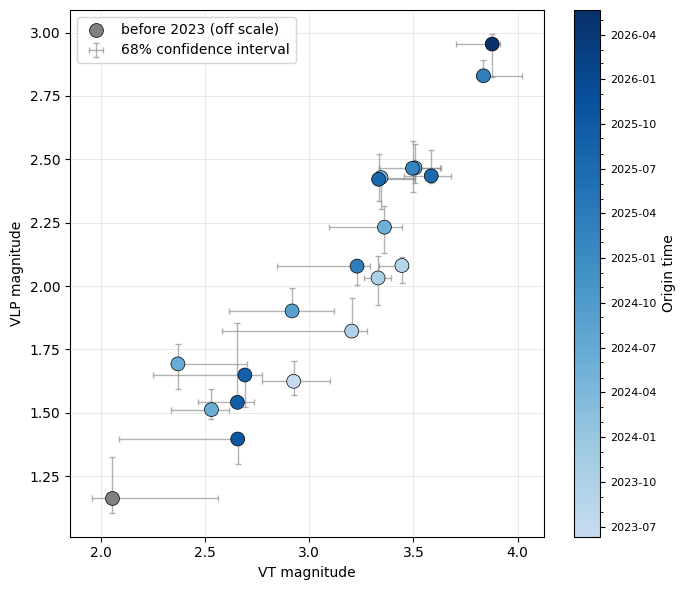

In [20]:
# VT best magnitude vs VLP best magnitude, coloured by origin time
# the 2018 event is far from all the others in time: plotted in gray, off scale
color_time_min = datetime(2023, 1, 1)     # CHANGE: start of the colour scale

t_num = mdates.date2num(event_time)
in_scale = np.array([t >= color_time_min for t in event_time])

fig, ax = plt.subplots(figsize=(7, 6))

# 68% confidence intervals, behind the markers
ax.errorbar(vt_best, vlp_best, xerr=vt_err, yerr=vlp_err, fmt='none',
            ecolor='gray', elinewidth=1.0, capsize=2, alpha=0.6, zorder=1,
            label='68% confidence interval')

ax.scatter(vt_best[~in_scale], vlp_best[~in_scale], s=100, color='gray',
           edgecolor='k', linewidth=0.5, zorder=3,
           label=f'before {color_time_min.year} (off scale)')

# 'Blues' without its lightest 25%: those steps are nearly invisible on white
cmap = LinearSegmentedColormap.from_list(
    'Blues_cut', plt.get_cmap('Blues')(np.linspace(0.25, 1.0, 256)))

norm = Normalize(vmin=t_num[in_scale].min(), vmax=t_num[in_scale].max())
sc = ax.scatter(vt_best[in_scale], vlp_best[in_scale], s=100, c=t_num[in_scale],
                cmap=cmap, norm=norm, edgecolor='k', linewidth=0.5, zorder=3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Origin time')
cbar.ax.yaxis.set_major_locator(mdates.MonthLocator(interval=3))
cbar.ax.yaxis.set_minor_locator(mdates.MonthLocator(interval=1))
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
cbar.ax.tick_params(which='both', labelsize=8)

ax.set_xlabel('VT magnitude')
ax.set_ylabel('VLP magnitude')
ax.grid(True, alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc=2)
plt.tight_layout()
plt.savefig(plot_filename)
plt.show()